In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
csv_filename = "../CleanData/df_data_with_pca.csv"
df_data = pd.read_csv(csv_filename)
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91209 entries, 0 to 91208
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PCA_0       91209 non-null  float64
 1   PCA_1       91209 non-null  float64
 2   PCA_2       91209 non-null  float64
 3   PCA_3       91209 non-null  float64
 4   PCA_4       91209 non-null  float64
 5   gid         91209 non-null  object 
 6   visteam     91209 non-null  object 
 7   hometeam    91209 non-null  object 
 8   site        91209 non-null  object 
 9   wteam       91209 non-null  object 
 10  lteam       91209 non-null  object 
 11  date        91209 non-null  object 
 12  teamID      91209 non-null  object 
 13  yearID      91209 non-null  int64  
 14  score_diff  91209 non-null  int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 10.4+ MB


In [21]:
for col in ['gid', 'visteam', 'hometeam', 'site', 'wteam', 'lteam', 'teamID']:
    df_data[col] = df_data[col].astype('category')

df_data['date'] = pd.to_datetime(df_data['date'])

#### model with XGBoost

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

y = df_data['score_diff']
df_data_vars = df_data.drop(columns=['score_diff', 'gid', 'wteam', 'lteam', 'date'])
X_train, X_test, y_train, y_test = train_test_split(df_data_vars, y, test_size=0.2, random_state=123)

reg_xgb = XGBRegressor(max_depth = 3, learning_rate = 0.1, n_estimators = 100, n_jobs=2, objective='reg:squarederror', random_state=500, enable_categorical=True)
reg_xgb.fit(X_train, y_train)

pred_xgb = reg_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print('RMSE Xgboost: {:.3f}'.format(rmse_xgb))

RMSE Xgboost: 3.807


In [23]:
# try to predict a winner based on score_diff
df_xgboost_pred = X_test.assign(
    score_diff_pred = pred_xgb
)
correct_pred = 0
incorrect_pred = 0
for i, row in df_xgboost_pred.iterrows():
    if row['score_diff_pred'] > 0 and y[i] > 0:
        correct_pred += 1
    elif row['score_diff_pred'] < 0 and y[i] < 0:
        correct_pred += 1
    else:
        incorrect_pred += 1

print("Correct Predictions:", correct_pred, "Incorrect predictions:", incorrect_pred)
print("Percentage of correct pred:", correct_pred / (correct_pred + incorrect_pred))

Correct Predictions: 12128 Incorrect predictions: 6114
Percentage of correct pred: 0.6648393816467493


In [24]:
# Filter for rows where 'visteam' and 'hometeam' are different
df_filtered = df_data[df_data['visteam'] != df_data['hometeam']]

# Create reverse pairs (where hometeam and visteam are swapped)
reverse_pairs = df_filtered.copy()
reverse_pairs['visteam'], reverse_pairs['hometeam'] = reverse_pairs['hometeam'], reverse_pairs['visteam']

# Merge original data with the reverse pair data to find duplicated pairs
duplicates = pd.merge(df_filtered, reverse_pairs, on=['visteam', 'hometeam'], how='inner')

# Show the duplicated rows
duplicates.head()

,PCA_0_x,PCA_1_x,PCA_2_x,PCA_3_x,PCA_4_x,gid_x,visteam,hometeam,site_x,wteam_x,...,PCA_3_y,PCA_4_y,gid_y,site_y,wteam_y,lteam_y,date_y,teamID_y,yearID_y,score_diff_y
0,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL11,BAL,...,-1.446274,0.079531,TEX198504220,ARL01,TEX,BAL,1985-04-22,TEX,1985,5
1,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL11,BAL,...,0.431627,-1.328423,TEX198504230,ARL01,BAL,TEX,1985-04-23,TEX,1985,-10
2,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL11,BAL,...,-0.289174,-0.746735,TEX198504240,ARL01,BAL,TEX,1985-04-24,BAL,1985,1
3,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL11,BAL,...,-0.985757,0.257216,TEX198508090,ARL01,TEX,BAL,1985-08-09,BAL,1985,-3
4,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL11,BAL,...,-0.262978,-0.321306,TEX198508100,ARL01,BAL,TEX,1985-08-10,BAL,1985,1


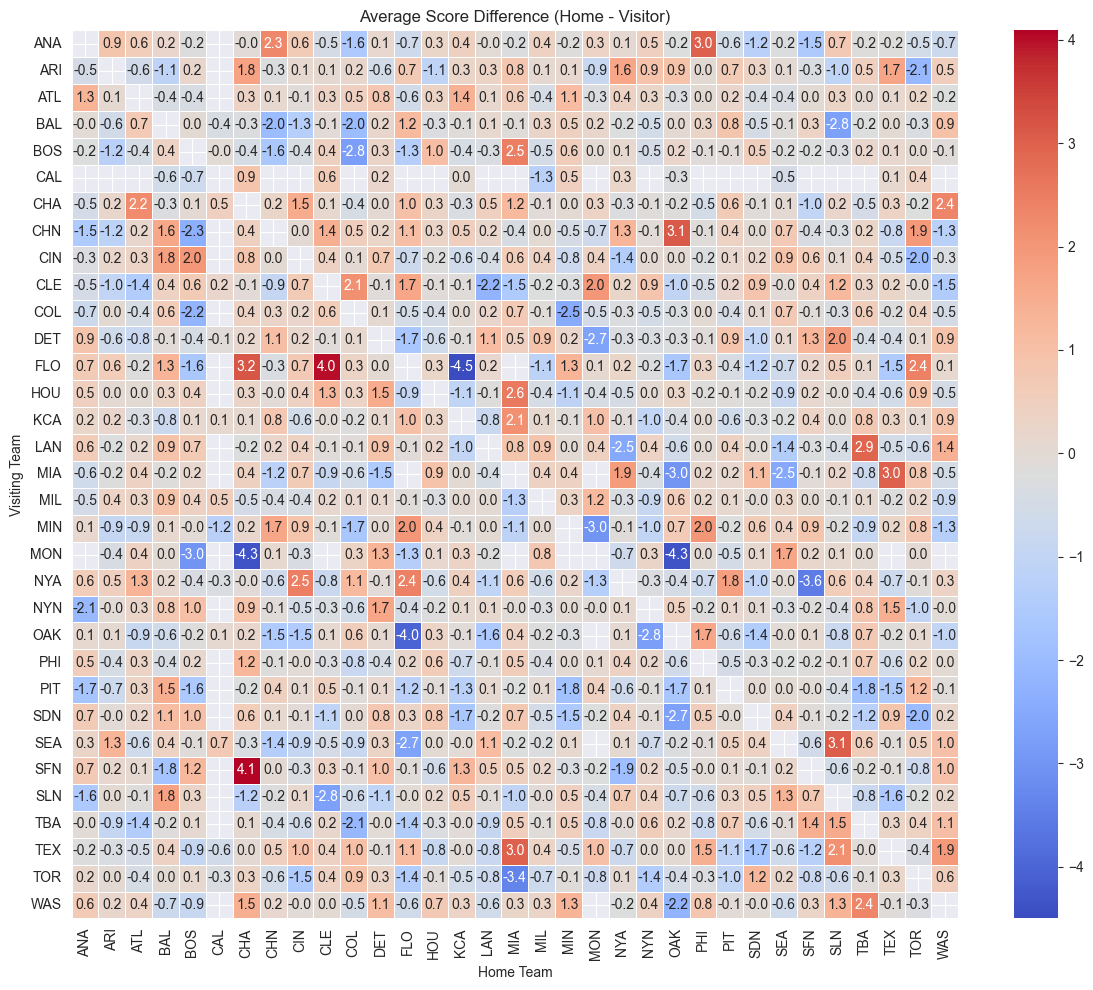

In [25]:
pivot = df_data.pivot_table(index='visteam', columns='hometeam', values='score_diff', aggfunc='mean', observed=False)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.5)
plt.title('Average Score Difference (Home - Visitor)')
plt.xlabel('Home Team')
plt.ylabel('Visiting Team')
plt.tight_layout()
plt.show()

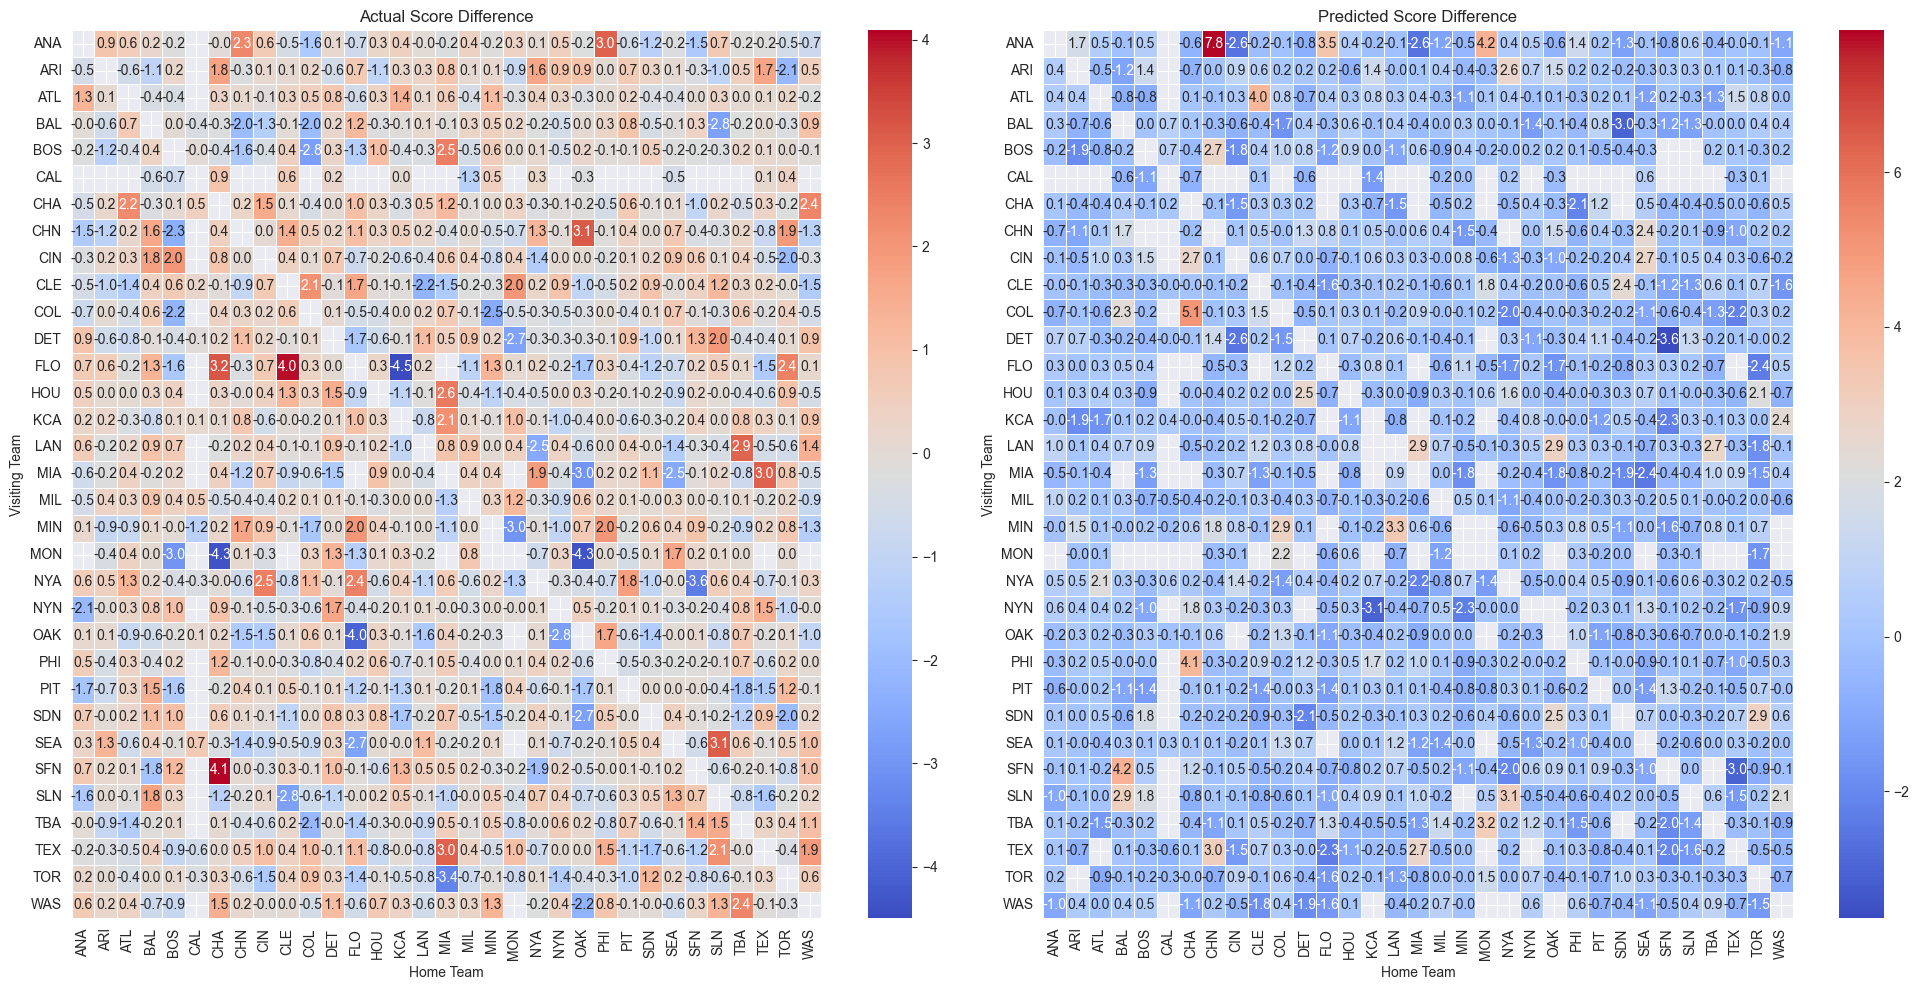

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Actual values
actual_pivot = df_data.pivot_table(index='visteam', columns='hometeam', values='score_diff', aggfunc='mean', observed=False)

# Predicted values
pred_pivot = df_xgboost_pred.pivot_table(index='visteam', columns='hometeam', values='score_diff_pred', aggfunc='mean', observed=False)


# Actual heatmap
sns.heatmap(actual_pivot, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[0], linewidths=0.5)
axes[0].set_title('Actual Score Difference')
axes[0].set_xlabel('Home Team')
axes[0].set_ylabel('Visiting Team')

# Predicted heatmap
sns.heatmap(pred_pivot, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1], linewidths=0.5)
axes[1].set_title('Predicted Score Difference')
axes[1].set_xlabel('Home Team')
axes[1].set_ylabel('Visiting Team')

plt.tight_layout()
plt.show()